## Load the default dataset in the librarie

In [1]:
import tensorflow as tf
#Digit MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [2]:
#check the input data set how it's looks, here i check the one image in the dataset(0 to 9)
x_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [3]:
#check the output data set
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

## Data preprocessing

In [4]:
#check the dataset shape
x_train.shape

(60000, 28, 28)

In [5]:
#here 60000 is the count of the images in the input train dataset and 28 rows and 28 columns on one image, so every image have 28 rows and 28 columns 

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
#In the X (input) dataset doesn't have channel,❗ Missing something → channel information
#CNN doesn’t know how many layers (depth) image has
#CNN expect the input like this (height, width, channels)
#So in the below code we initiate the channel value 
#(60000, 28, 28)
#        ⬇
#(60000, 28, 28, 1)

In [8]:
#Number of channels = 1
#1 → Grayscale image (black & white)
#3 → Color image (RGB)

In [9]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

In [10]:
x_train.shape

(60000, 28, 28, 1)

In [11]:
x_train.dtype

dtype('uint8')

In [12]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [13]:
#Normalize pixel values (0–255 → 0–1)
#pixel= pixel / 255 

In [14]:
x_train /= 255
x_test /=255

In [15]:
x_train[1]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

## Creating the CNN brain

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

#Creating base neural netweok 
model= Sequential()
#Convolutional 
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
#28 Filters, kernal_size 3 x 3 each filter, it will take 3 rows and 3 columns in the channels data, the default (strides=1, padding = 'Valid', activation = 'relu')

model.add(MaxPooling2D(pool_size=(2,2)))
#it's more like Dimensionality Reduction, reduce the rows & columns size keep or increase the chennals size (28/2, 28/2, 28)

model.add(Flatten())
#Flatten It transitions the model from seeing the data as a 2D image to seeing it as a 1D list of features.

#Neural Network
model.add(Dense(128, activation=tf.nn.relu))

model.add(Dropout(0.2))
#Output layer
model.add(Dense(10,activation=tf.nn.softmax))

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

In [24]:
##Summary to view the Details of the CNN process
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 26, 26, 28)        280       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 13, 13, 28)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 4732)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               605824    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                      

In [18]:
#In CNN the model is best for Convolution
#samples=60000 , features_per_sample=784, total_values=47040000
#Since the data set have 28x28 = 784 inputes per image, in this have 600000 images so totally 28x28x60000 = 47,040,000 inputes.
#The CNN convolves high-dimensional input data into low-dimensional feature maps through successive layers.

In [19]:
#model to create 28 different "feature detectors." 
#Each filter will look for a different pattern (like an edge, a curve, or a texture). The output of this layer will have a depth of 28.
#kernel_size=(3,3): This is the size of each filter (a 3 \times 3 grid of weights).
#input_shape: This is where you define your input channels (e.g., (28, 28, 1) for grayscale or (28, 28, 3) for RGB color).

In [20]:
#data comes into this in first cnn layer with a shape of (28, 28, 28) (28 filters):Width: 28 / 2 = 14, Height: 28 / 2 = 14, New Shape: (14, 14, 28)

## work flow of the layer 

In [21]:
""" 
Data is a 3D cube (a tensor). 
If we follow previous layers
1. Input: (28, 28, 1) — A single grayscale image.
2. After Conv2D (28 filters): (26, 26, 28) — Assuming default "valid" padding.
3. After MaxPooling2D (2,2): (13, 13, 28) — The dimensions are cut in half.

The Flatten() layer takes that (13, 13, 28) cube and unrolls all the numbers into one long, vertical line. 
13 \times 13 \times 28 = 4,732 neurons this neurons data will move to the Neural Network here will process like ANN

"""

' \nData is a 3D cube (a tensor). \nIf we follow previous layers\n1. Input: (28, 28, 1) — A single grayscale image.\n2. After Conv2D (28 filters): (26, 26, 28) — Assuming default "valid" padding.\n3. After MaxPooling2D (2,2): (13, 13, 28) — The dimensions are cut in half.\n\nThe Flatten() layer takes that (13, 13, 28) cube and unrolls all the numbers into one long, vertical line. \n13 \times 13 \times 28 = 4,732 neurons this neurons data will move to the Neural Network here will process like ANN\n\n'

## Compiling the model 

In [26]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [34]:
result=model.fit(x=x_train,y=y_train, epochs=10, batch_size=100)
#TensorFlow defaults batch_size was 32.

Epoch 1/10
600/600 [==============================] - 12s 19ms/step - loss: 0.0610 - accuracy: 0.9848
Epoch 2/10
600/600 [==============================] - 11s 19ms/step - loss: 0.0296 - accuracy: 0.9909
Epoch 3/10
600/600 [==============================] - 12s 19ms/step - loss: 0.0200 - accuracy: 0.9935
Epoch 4/10
600/600 [==============================] - 12s 20ms/step - loss: 0.0159 - accuracy: 0.9945
Epoch 5/10
600/600 [==============================] - 11s 18ms/step - loss: 0.0114 - accuracy: 0.9960
Epoch 6/10
600/600 [==============================] - 11s 19ms/step - loss: 0.0101 - accuracy: 0.9962
Epoch 7/10
600/600 [==============================] - 11s 18ms/step - loss: 0.0080 - accuracy: 0.9972
Epoch 8/10
600/600 [==============================] - 11s 18ms/step - loss: 0.0070 - accuracy: 0.9974
Epoch 9/10
600/600 [==============================] - 11s 19ms/step - loss: 0.0068 - accuracy: 0.9977
Epoch 10/10
600/600 [==============================] - 11s 18ms/step - loss: 0.005

In [40]:
model.evaluate(x_test, y_test)
#10,000 / 32 (default batch size) = 312.5
#32 is the default batch_size

313/313 [==============================] - 1s 2ms/step - loss: 0.0625 - accuracy: 0.9859


[0.062469396740198135, 0.9858999848365784]

In [42]:
#Check the image data

1/1 [==============================] - 0s 85ms/step
6


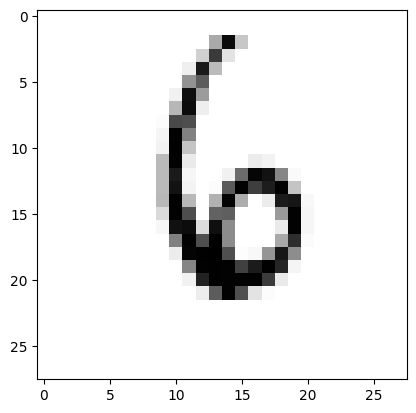

In [41]:
import matplotlib.pyplot as plt
image_index = 6900
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
predict = x_test[image_index].reshape(28,28)
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())

## Evaluation metrics

In [70]:
y_pred=model.predict(x_test)
#The default batch_size was 32, so 10000 / 32 = 1875 batches 

313/313 [==============================] - 1s 2ms/step


In [71]:
y_pred[0]
#pred data structure was different so we can't compare this data with the actual data(y_test)

array([1.0006449e-15, 1.0157647e-12, 5.3735776e-11, 3.8103622e-12,
       9.3754378e-17, 4.2268222e-18, 1.0701511e-20, 1.0000000e+00,
       8.0819869e-15, 1.9122072e-15], dtype=float32)

In [72]:
y_test[0]

7

In [73]:
import numpy as np
y_pred=np.argmax(y_pred, axis=1)
#after the argmax the pred data was ready to compare with actual data

In [74]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

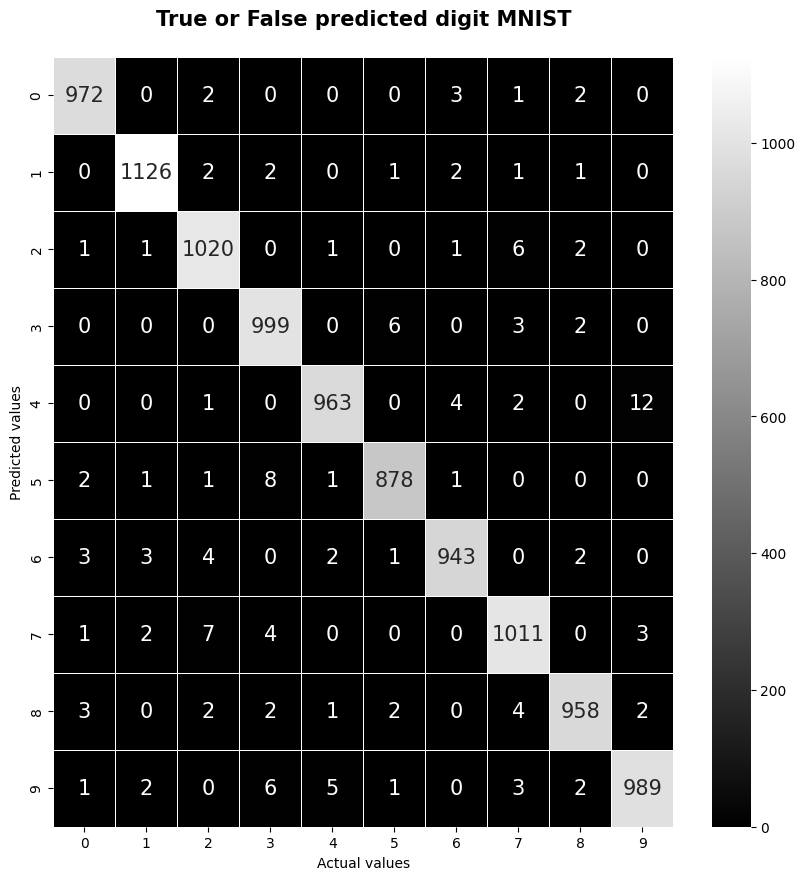

In [81]:
#Confusion matrix for Digit MNIST
#check the metric using heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns

con_mat=confusion_matrix(y_test, y_pred)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size': 15}, linewidths=0.5, fmt='d', cmap='gray')
plt.title("True or False predicted digit MNIST\n",fontweight='bold',fontsize=15)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

In [82]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



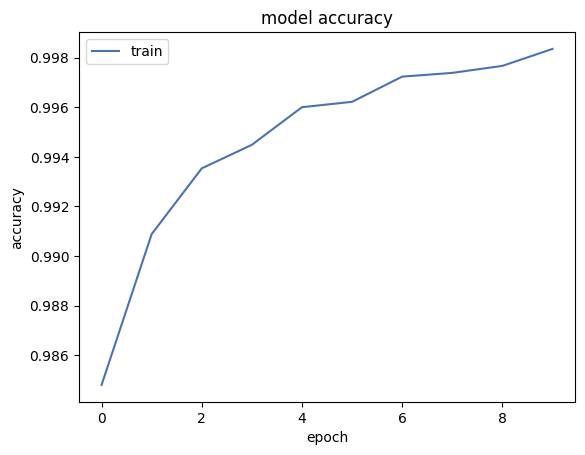

In [84]:
# summarize history for accuracy
plt.plot(result.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

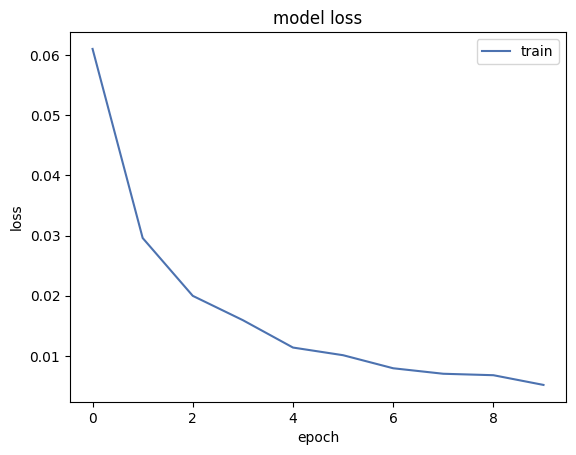

In [85]:
plt.plot(result.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

## User test

In [118]:
y_pred_sing = model.predict(x_test[[2]])
y_predicts_single = np.argmax(y_pred_sing, axis=1)
#y_test was already in the correct order so no need to preprocessor the data

1/1 [==============================] - 0s 17ms/step


In [119]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [120]:
y_predicts_single

array([1], dtype=int64)

In [117]:
x_test[2]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

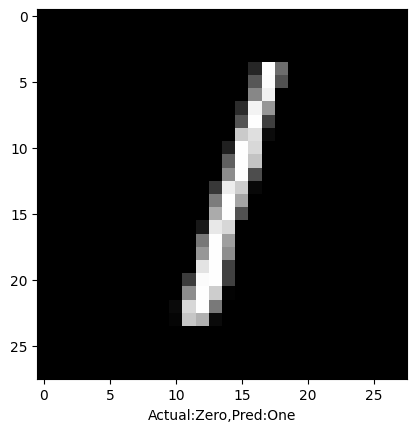

In [112]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.imshow(x_test[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test[2])],col_names[y_predicts_single[0]]))
plt.show()